In [1]:
from src.LM.lm_roberta_xml import(
    tokenizer, model,
    create_dataloaders, train_model, evaluate_model
)

from sklearn.preprocessing import LabelEncoder
from src.data_loader import load_data
from src.preprocess import clean_text
from src.LM.lm_roberta_xml import get_class_weights

from sklearn.model_selection import train_test_split
import torch

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [2]:

df = load_data("/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv")
df['Text'] = df['Text'].apply(clean_text)  

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

# ulozenie katagorii
target_names = le.classes_.tolist()


# rozdelenie datasetu
X_train_text, X_test_text, y_train_encoded, y_test_encoded = train_test_split(
    df['Text'].tolist(), 
    df['Category_encoded'].tolist(),
    test_size=0.2, 
    random_state=42,
    stratify=df['Category_encoded']
)


Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...


Epoch 1/7, Loss: 0.1251
Epoch 2/7, Loss: 0.1278
Epoch 3/7, Loss: 0.1155
Epoch 4/7, Loss: 0.1401
Epoch 5/7, Loss: 0.1504
Epoch 6/7, Loss: 0.1436
Epoch 7/7, Loss: 0.1325
[0, 1]
[<class 'int'>, <class 'int'>]
Best threshold (F1-optimal): 0.567
Best F1 score: 0.560
              precision    recall  f1-score   support

           0       0.89      0.41      0.56       101
           1       0.35      0.87      0.50        38

    accuracy                           0.53       139
   macro avg       0.62      0.64      0.53       139
weighted avg       0.74      0.53      0.54       139



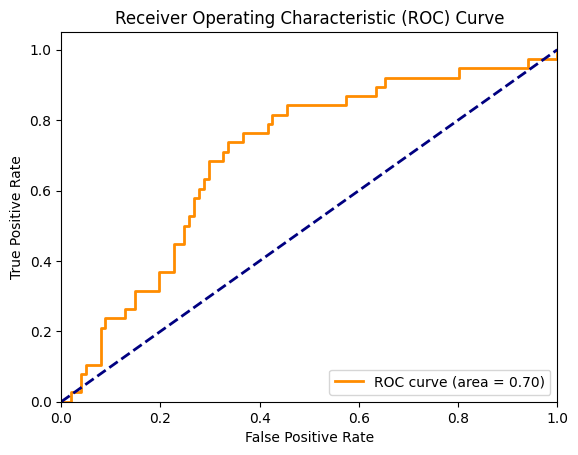

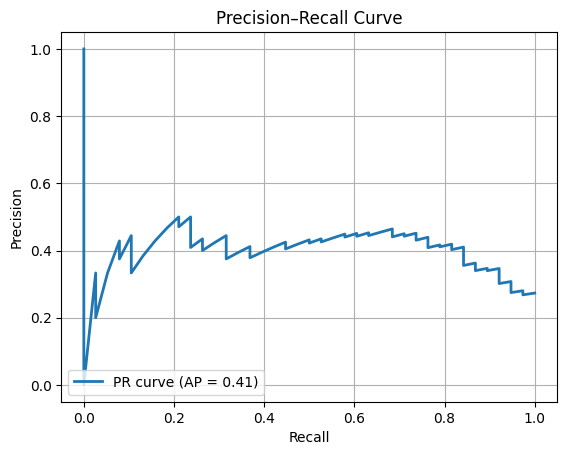

In [ ]:
# konverzia textu a labelov na PyTorch Dataloaders objekty
# batchovanie, rozdelenie na test / train
train_loader, test_loader = create_dataloaders(X_train_text, y_train_encoded, X_test_text, y_test_encoded)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# trenovanie LM
class_weights = get_class_weights(y_train_encoded, device)
trained_model = train_model(model, train_loader, epochs=5, lr=2e-5, use_focal_loss=True, class_weights=class_weights)
trained_model.save_pretrained("models/xlm_roberta_binary")
tokenizer.save_pretrained("models/xlm_roberta_binary")

print(target_names)
print([type(x) for x in target_names])
# evaluacia modelu
evaluate_model(trained_model, test_loader, label_names=target_names)

